In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Imports

In [4]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split

from src.eda_utils import eda_category, eda_numeric

warnings.filterwarnings("ignore", category=UserWarning)

# Exploratory Data Analysis

## Preliminary Analysis

In [5]:
# reading and inspecting the data
raw_df = pd.read_csv(
    "../data/bank-additional-full.csv",
    sep=";"
)
display(raw_df)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [6]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [7]:
raw_df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [8]:
# class distribution of the target variable
(raw_df['y'].value_counts(normalize=True) * 100).round(2)

y
no     88.73
yes    11.27
Name: proportion, dtype: float64

In [9]:
# number of categorical and numerical features
cat_cols = raw_df.drop(columns=['y']).select_dtypes(include=['object', 'string']).columns
num_cols = raw_df.select_dtypes(include='number').columns

print(f'Number of categorical features: {len(cat_cols)}')
print(f'Number of numerical features: {len(num_cols)}')

Number of categorical features: 10
Number of numerical features: 10


* The dataset contains 41,888 observations and 20 features (excluding the target). There are no missing values.
* The data contains both numerical and categorical features:
   - numerical features - 10
   - categorical features - 10
* No obvious anomalies or incorrect values were detected at this stage.
* The target variable is imbalanced: the 'no' class accounts for ~89%, 'yes' - ~11%.

## Data Preparation for Further Work

In [10]:
# splitting data into train and validation sets in an 80/20 ratio
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['y'])

train_df = train_df.copy()
val_df = val_df.copy()

# create mapping column 'yes' = 1, 'no' = 0
train_df['y_num'] = train_df['y'].map({'yes': 1, 'no': 0})
val_df['y_num'] = val_df['y'].map({'yes': 1, 'no': 0})

# creating target mapping column 'yes' = 1, 'no' = 0
input_cols = [col for col in train_df.columns if col not in ['y', 'y_num']]

target_col = 'y_num'
target_cat_col = 'y'

## GENERAL CUSTOMER DATA ANALYSIS

### Analysis of the 'age' variable

==================== Column: age ====================
Total number of values: 32950
Number of unique values: 75
Number of missing values: 0
Skewness: 0.76
Outliers: 368
Median "no": 38.0
Median "yes": 37.0
count    32950.00
mean        40.01
std         10.40
min         17.00
25%         32.00
50%         38.00
75%         47.00
max         98.00
Name: age, dtype: float64


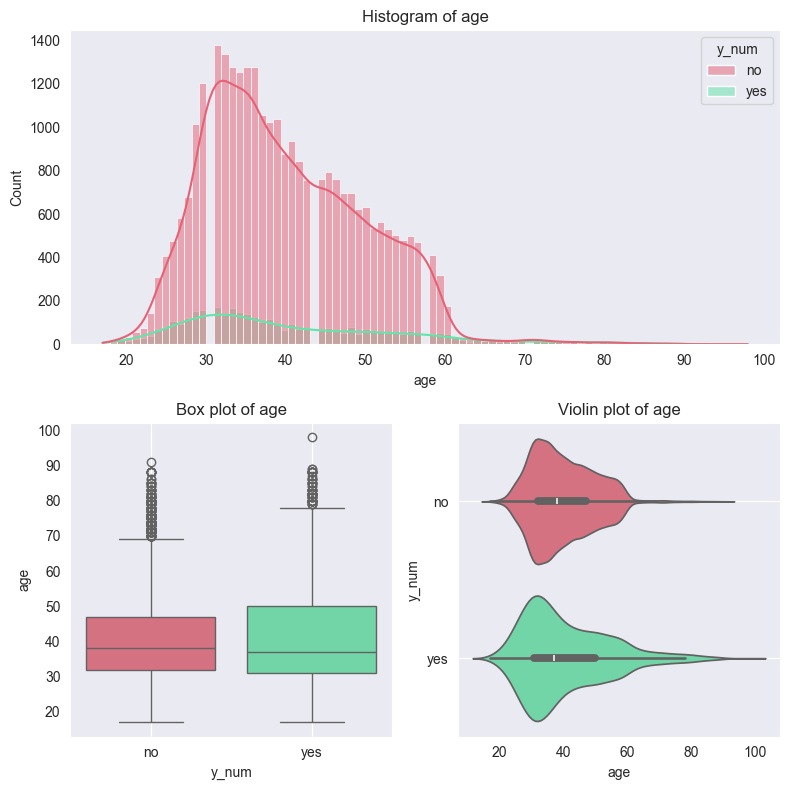

In [11]:
eda_numeric(train_df, 'age', target_col)

* The 'age' column contains numerical values; there are no missing values.
* The range of values is from 17 to 98 years, which is entirely realistic.
* Data visualization shows:
   - a small number of young clients
   - the majority of clients are aged 30-50
   - the distribution is right-skewed (confirmed by a skewness of 0.76)
   - the age distributions for y='yes' and y='no' are quite similar

**Hypothesis:** age might not be a strong predictor for the target variable, but it could be a useful feature for improving the model overall.

### Analysis of the 'job' variable
– type of employment (categorical variable)

==================== Column: job ====================
Total number of values: 32950
Number of unique values: 12
Number of missing values: 0


job,admin.,blue-collar,technician,services,management,retired,entrepreneur,self-employed,housemaid,unemployed,student,unknown
value_counts,8314.00,7441.00,5400.00,3196.0,2345.00,1366.00,1160.00,1099.00,855.00,798.00,711.00,265.0
value_percentage,25.23,22.58,16.39,9.7,7.12,4.15,3.52,3.34,2.59,2.42,2.16,0.8


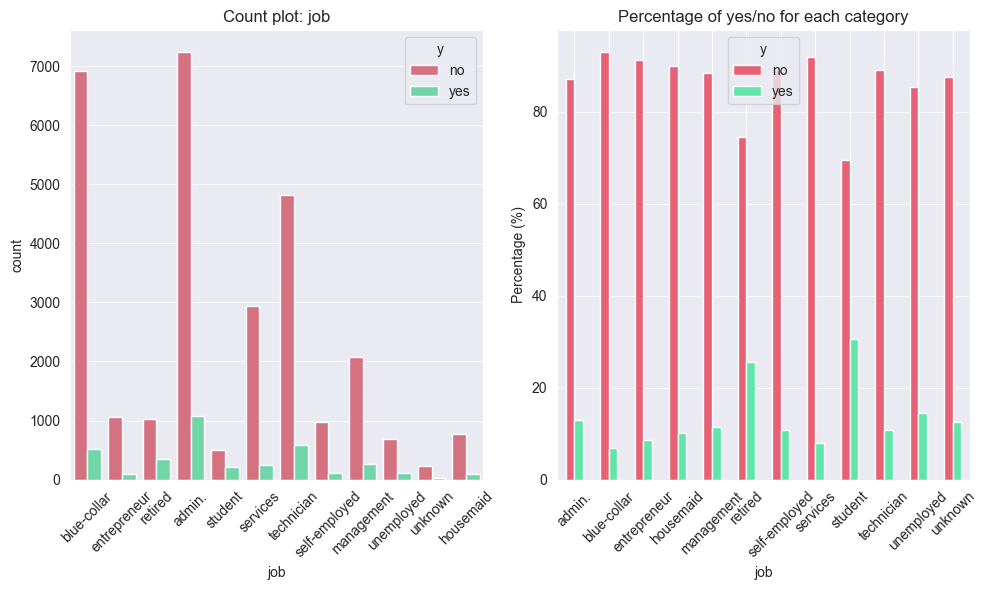

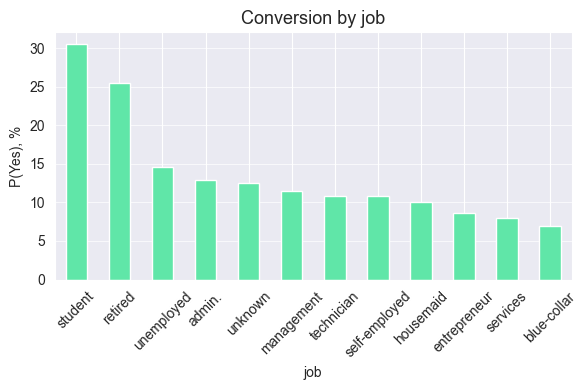

In [12]:
eda_category(train_df, 'job', target_cat_col)

* The 'job' column contains 32,950 observations and 12 unique values; there are no missing values.
* The categories of this feature are imbalanced:
  - 64% of the values belong to 3 out of the 12 categories (admin., blue-collar, technician)
  - 7 out of the 12 categories account for less than 4% of the total data
  - the 'unknown' category contains only 1% of the data
* Data visualization shows:
   - the probability of a positive response differs significantly across categories
   - most occupations differ slightly from one another: 10-14% of positive responses
   - the 'student' and 'retired' categories have a significantly higher probability of a positive response compared to others

**Hypothesis:** the 'job' feature is quite informative and could be a useful predictor.

### Analysis of the 'marital' variable
– marital status

==================== Column: marital ====================
Total number of values: 32950
Number of unique values: 4
Number of missing values: 0


marital,married,single,divorced,unknown
value_counts,19953.00,9257.00,3675.00,65.0
value_percentage,60.56,28.09,11.15,0.2


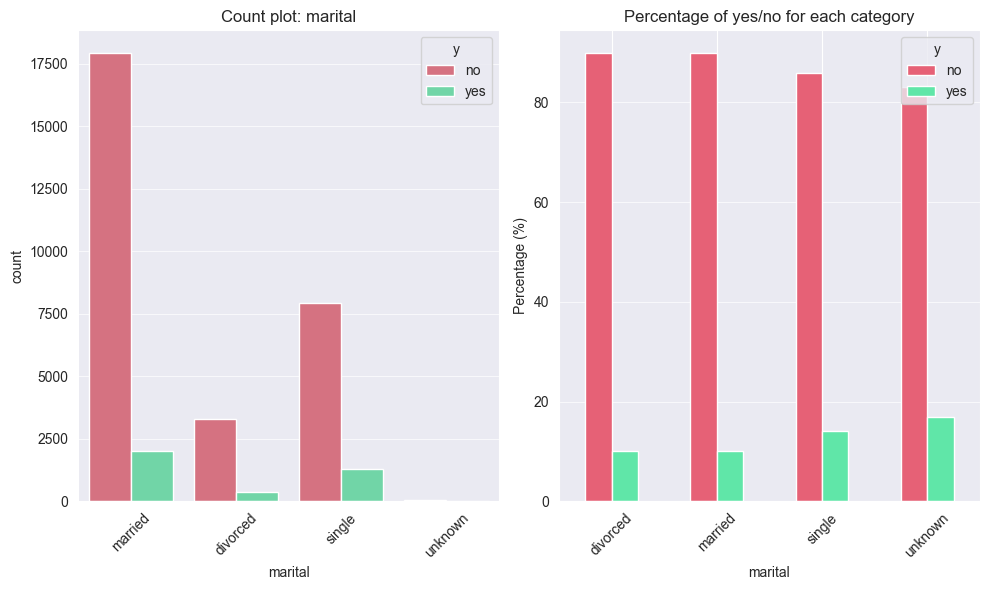

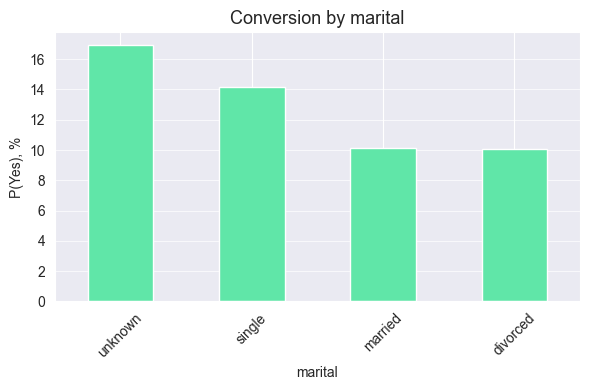

In [13]:
eda_category(train_df, 'marital', target_cat_col)

* The 'marital' column contains 32,950 observations and 4 unique values; there are no missing values.
* The categories of this feature are imbalanced:
  - married clients constitute the majority of bank clients: ~61%
  - clients with an unknown marital status account for 0.2%
* Data visualization shows:
   - the proportion of negative responses in each category exceeds 80%
   - single clients are more inclined towards a positive response
   - the 'unknown' category has the highest proportion among positive responses, but the sample size is very small (0.2%), so the data may be unstable

**Hypothesis:** the 'marital' feature is likely not a strong predictor, but it can provide additional information for the model, as a client's marital status may influence the decision to open a deposit.

### Analysis of the 'education' variable
– level of education

==================== Column: education ====================
Total number of values: 32950
Number of unique values: 8
Number of missing values: 0


education,university.degree,high.school,basic.9y,professional.course,basic.4y,basic.6y,unknown,illiterate
value_counts,9736.00,7596.00,4826.00,4192.00,3322.00,1865.00,1397.00,16.00
value_percentage,29.55,23.05,14.65,12.72,10.08,5.66,4.24,0.05


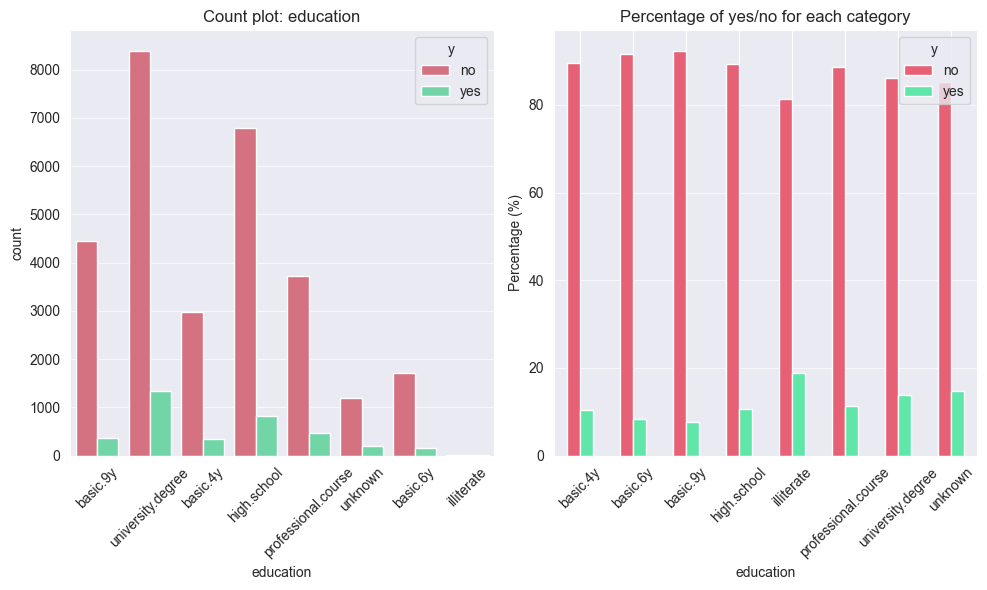

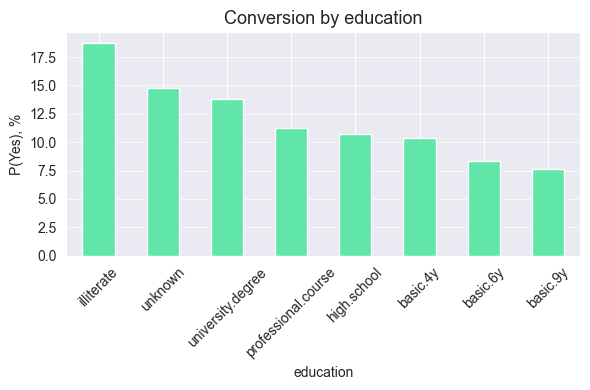

In [14]:
eda_category(train_df, 'education', target_cat_col)

* The 'education' column contains 32,950 observations and 8 unique categories; there are no missing values.
* The categories of this feature are imbalanced:
  - 2 categories ('university.degree' and 'high.school') together account for 52.5% of all observations
  - the 'illiterate' category accounts for only 0.05%
* Data visualization shows:
   - the proportion of negative responses in each category exceeds 80%, while the proportion of positive responses varies slightly depending on the level of education
   - clients with a university degree are slightly more likely to give a positive response
   - the 'illiterate' and 'unknown' categories have the highest proportions of positive responses, but their sample sizes are very small (0.05% and 4.24% respectively), so the data may be unstable

**Hypothesis:** the client's education level may be related to their willingness to open a deposit, so the 'education' feature can be informative for the model.

### Analysis of the 'default' variable
– whether the client has credit in default

==================== Column: default ====================
Total number of values: 32950
Number of unique values: 3
Number of missing values: 0


default,no,unknown,yes
value_counts,26007.00,6940.00,3.00
value_percentage,78.93,21.06,0.01


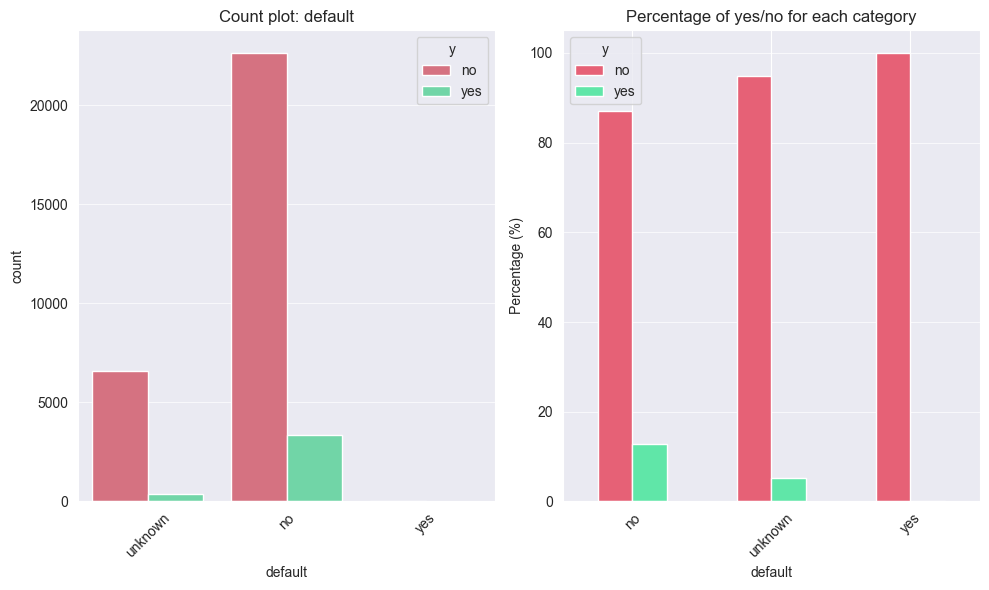

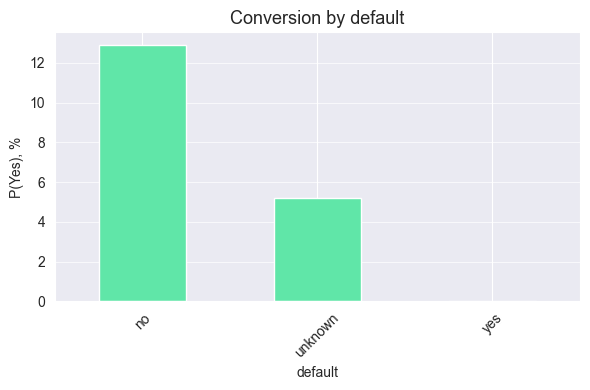

In [15]:
eda_category(train_df, 'default', target_cat_col)

* The 'default' column contains 32,950 observations and 3 unique categories; there are no missing values.
* The categories of this feature are imbalanced:
  - clients with no credit in default account for ~79% of all observations
  - clients with credit in default account for only 0.01%, which may not carry useful information for the model
* Data visualization shows:
   - the 'no' category has the highest conversion rate (~13%)
   - the 'unknown' category has a conversion rate of ~5%
   - the 'yes' category has zero conversion, but this may be the result of a very small amount of data (only 3 cases)

**Hypothesis:** the 'default' feature has a certain connection with the target variable (different conversion rates for 'no' and 'unknown'), but it may have a limited impact on the model because the 'yes' category is extremely rare, making the estimate unreliable.

### Analysis of the 'housing' variable
– whether the client has a housing loan

==================== Column: housing ====================
Total number of values: 32950
Number of unique values: 3
Number of missing values: 0


housing,yes,no,unknown
value_counts,17254.00,14900.00,796.00
value_percentage,52.36,45.22,2.42


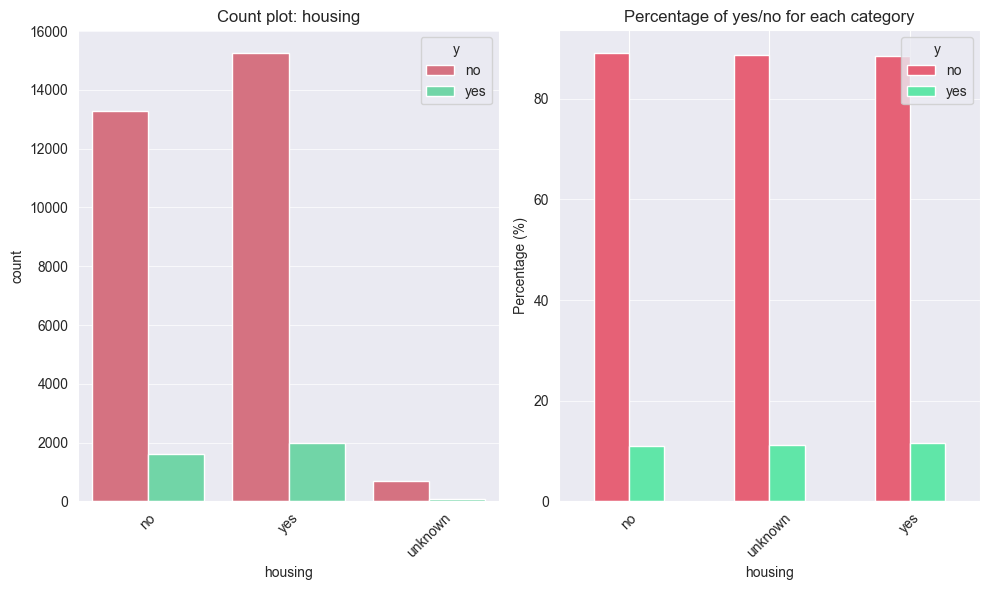

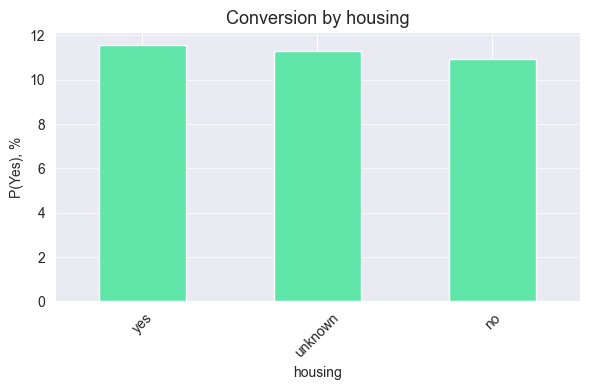

In [16]:
eda_category(train_df, 'housing', target_cat_col)

* The 'housing' column contains 32,950 observations and 3 unique categories; there are no missing values.
* The main categories of this feature ('yes' and 'no') are balanced relative to each other: ~52% and ~45% respectively.
* Data visualization shows:
   - the conversion rate for the target is almost identical across all categories (~11%), which may indicate a weak relationship between having a housing loan and a positive response to opening a deposit.

**Hypothesis:** the 'housing' feature may have a limited impact on the model, as the conversion rate varies little across different categories.

### Analysis of the 'loan' variable
– whether the client has a personal loan

==================== Column: loan ====================
Total number of values: 32950
Number of unique values: 3
Number of missing values: 0


loan,no,yes,unknown
value_counts,27131.00,5023.00,796.00
value_percentage,82.34,15.24,2.42


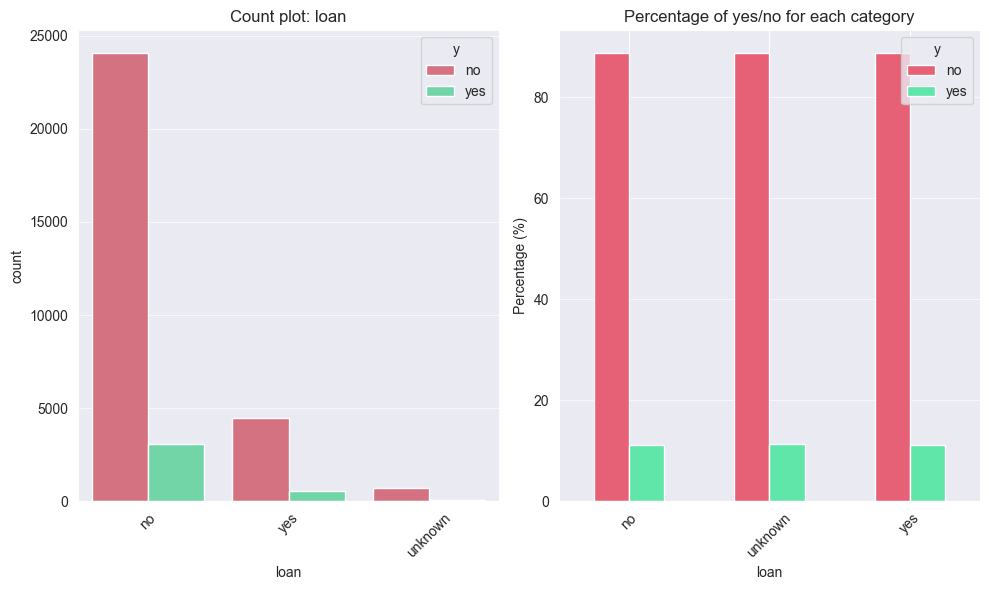

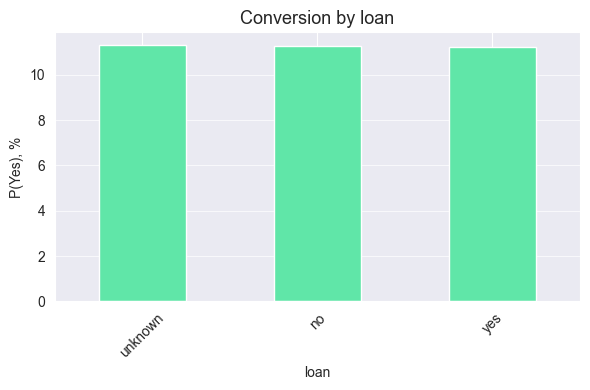

In [17]:
eda_category(train_df, 'loan', target_cat_col)


* The 'loan' column contains 32,950 observations and 3 unique categories; there are no missing values.
* The categories of this feature are imbalanced: 'no' - ~82%, 'yes' - ~15%, 'unknown' - ~2%
* Data visualization shows:
   - the conversion rate for the target is almost identical across all categories (~11%), which may indicate a weak relationship between having a personal loan and a positive response to opening a deposit.

**Hypothesis:** the 'loan' feature may have a limited impact on the model, as the conversion rate varies little across different categories.

**Hypothesis for the "General Client Data" section:**
- the strongest predictors may be the 'job' and 'education' features (they show more significant differences in conversion rates across their categories)
- other features may provide additional information for the model
- there are rare categories that could act as statistical noise and lead to unreliable estimates.

Certain client segments (students, retirees, single individuals, highly educated clients) demonstrate higher conversion rates, but their impact should be evaluated in combination with other features.

## DATA ANALYSIS OF THE LAST CONTACT WITHIN THE CURRENT CAMPAIGN

### Analysis of the 'contact' variable
– contact communication type

==================== Column: contact ====================
Total number of values: 32950
Number of unique values: 2
Number of missing values: 0


contact,cellular,telephone
value_counts,20908.00,12042.00
value_percentage,63.45,36.55


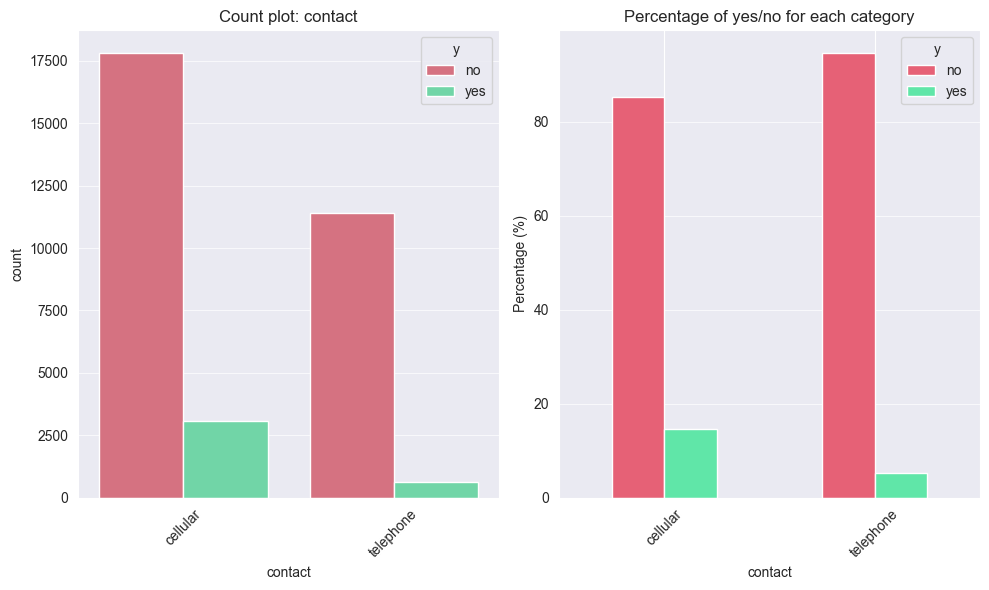

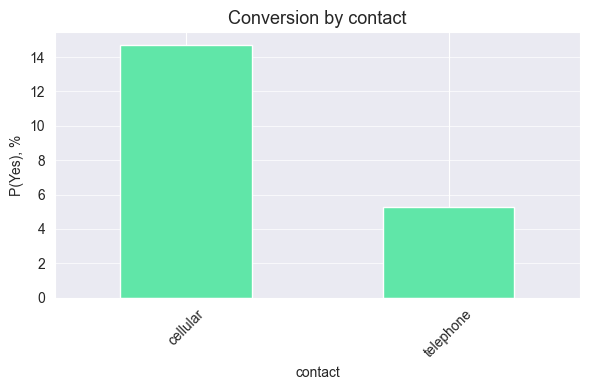

In [18]:
eda_category(train_df, 'contact', target_cat_col)

* The 'contact' column contains 32,950 observations and 2 unique categories; there are no missing values.
* The categories of this feature are imbalanced: 'cellular' accounts for ~63% and 'telephone' accounts for ~37% of observations.
* Data visualization shows a significant difference in conversion rates between categories:
  - 'cellular' - ~14%
  - 'telephone' - ~5%,

 which indicates a strong relationship between the communication type and a positive response to opening a deposit.

**Hypothesis:** the 'contact' feature is likely a strong predictor for the target variable.

### Analysis of the 'month' variable
– last contact month

==================== Column: month ====================
Total number of values: 32950
Number of unique values: 10
Number of missing values: 0


month,may,jul,aug,jun,nov,apr,oct,sep,mar,dec
value_counts,11011.00,5763.00,4948.00,4247.00,3266.00,2085.00,587.00,464.00,436.00,143.00
value_percentage,33.42,17.49,15.02,12.89,9.91,6.33,1.78,1.41,1.32,0.43


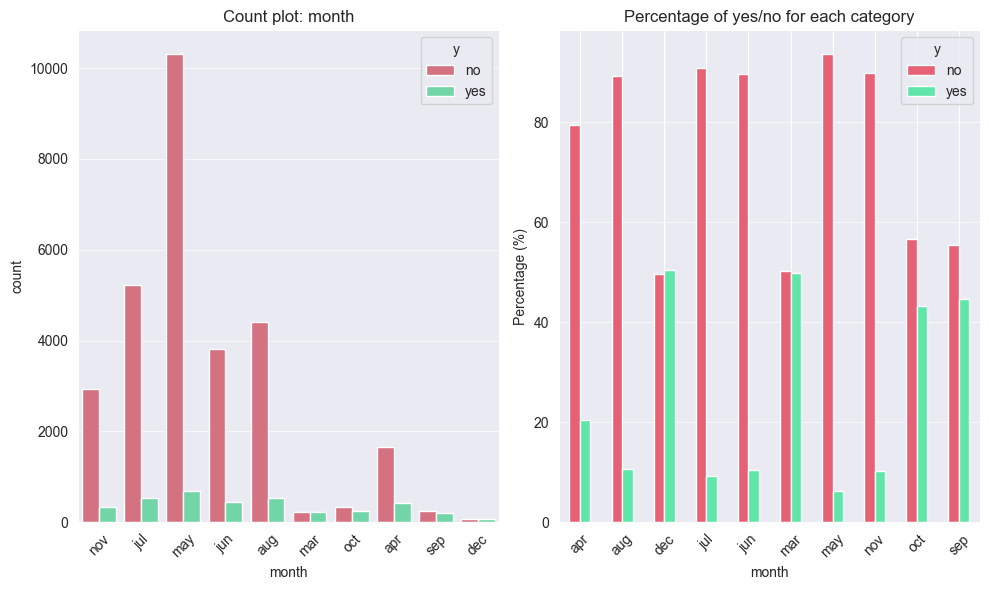

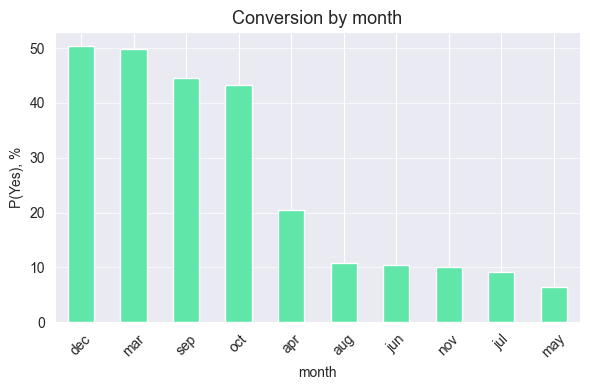

In [19]:
eda_category(train_df, 'month', target_cat_col)

* The 'month' column contains 32,950 observations and 10 unique categories; there are no missing values.
* The categories of this feature are imbalanced.
* Two months are missing from the data: January and February.
* Data visualization shows:
  - an inverse relationship between the number of calls and the conversion rate
  - the highest conversion rates are in December and March (~50%)
  - the lowest conversion rates are in July and May (less than 10%),

 which may reflect the timing and activity levels of banking campaigns rather than seasonal client behavior.

**Hypothesis:** the 'month' feature may reflect the intensity of marketing campaigns rather than seasonal decision-making patterns of clients regarding deposit placement.

### Analysis of the 'day_of_week' variable
– last contact day of the week

==================== Column: day_of_week ====================
Total number of values: 32950
Number of unique values: 5
Number of missing values: 0


day_of_week,thu,mon,wed,tue,fri
value_counts,6857.00,6812.00,6515.00,6444.00,6322.00
value_percentage,20.81,20.67,19.77,19.56,19.19


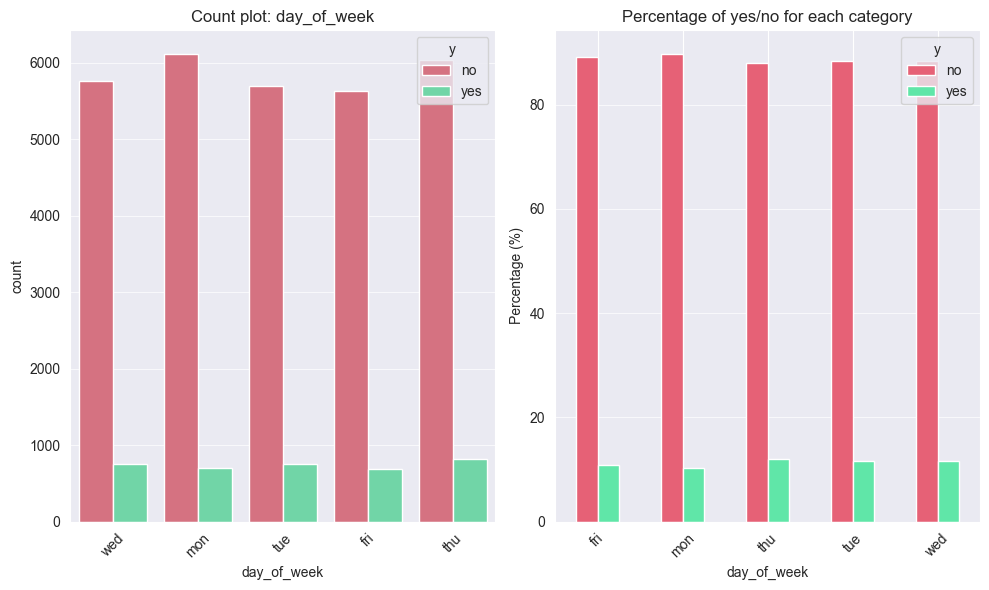

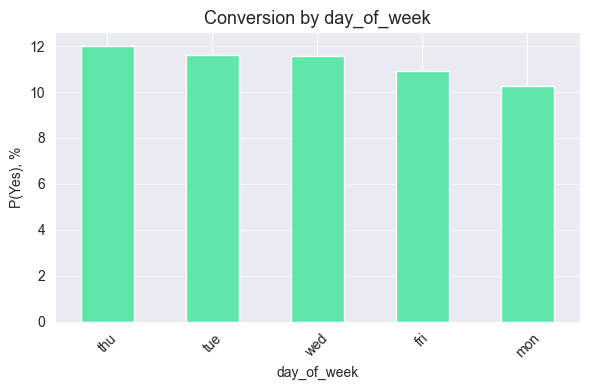

In [20]:
eda_category(train_df, 'day_of_week', target_cat_col)

* The 'day_of_week' column contains 32,950 observations and 5 unique categories; there are no missing values.
* The call distribution is balanced: each day of the week represents a share between ~19% and ~21%.
* Two days are missing from the data: Saturday and Sunday—likely because no campaigns were conducted on weekends.
* Data visualization shows:
  - the conversion rate for each day of the week fluctuates within 10–12%.

**Hypothesis:** the 'day_of_week' feature may be a weak predictor for the target variable.

### Analysis of the 'duration' variable

– last contact duration in seconds

==================== Column: duration ====================
Total number of values: 32950
Number of unique values: 1467
Number of missing values: 0
Skewness: 3.33
Outliers: 2366
Median "no": 164.0
Median "yes": 448.0
count    32950.00
mean       258.13
std        258.98
min          0.00
25%        103.00
50%        180.00
75%        319.00
max       4918.00
Name: duration, dtype: float64


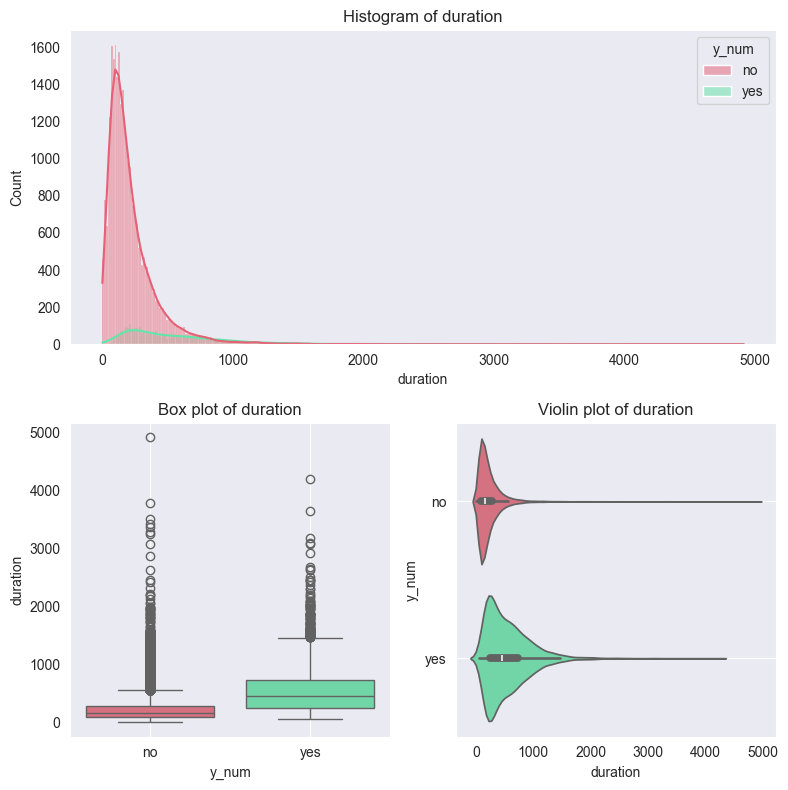

In [21]:
eda_numeric(train_df, 'duration', target_col)

* The 'duration' column contains numerical values; there are no missing values.
* The values range from 0 to 4,918 seconds, which appears realistic.
* Half of the calls last up to 180 seconds (3 minutes), with an average duration of 258 seconds (almost 4.5 minutes), but there are also very long conversations—up to 82 minutes.
* Data visualization shows:
  - strong skewness with a right-skewed distribution (skewness 3.33)
  - the median for 'yes' is significantly higher than the median for 'no' (448 vs. 164), indicating that longer call durations are associated with a higher probability of 'yes'.

**Hypothesis:** since the 'duration' value is unknown prior to the end of the call and has a strong relationship with the target variable, this column should be removed before model training to prevent data leakage.

**Hypothesis for the "Contact Data within the Current Campaign" section:**
- the strongest predictor may be the 'contact' feature (significant difference in conversion rates between categories)
- 'day_of_week' is likely a very weak predictor, but it may complement the overall information
- other features may provide additional information for the model
- 'duration' should be excluded from the model to prevent data leakage

It should be noted that the features in this section reflect the marketing campaigns of the banking institution rather than the behavioral patterns of the clients.

## ANALYSIS OF OTHER ATTRIBUTES

### Analysis of the 'campaign' variable
– number of contacts performed during this campaign and for this client (includes last contact)

==================== Column: campaign ====================
Total number of values: 32950
Number of unique values: 40
Number of missing values: 0
Skewness: 4.74
Outliers: 1916
Median "no": 2.0
Median "yes": 2.0
count    32950.00
mean         2.56
std          2.75
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         56.00
Name: campaign, dtype: float64


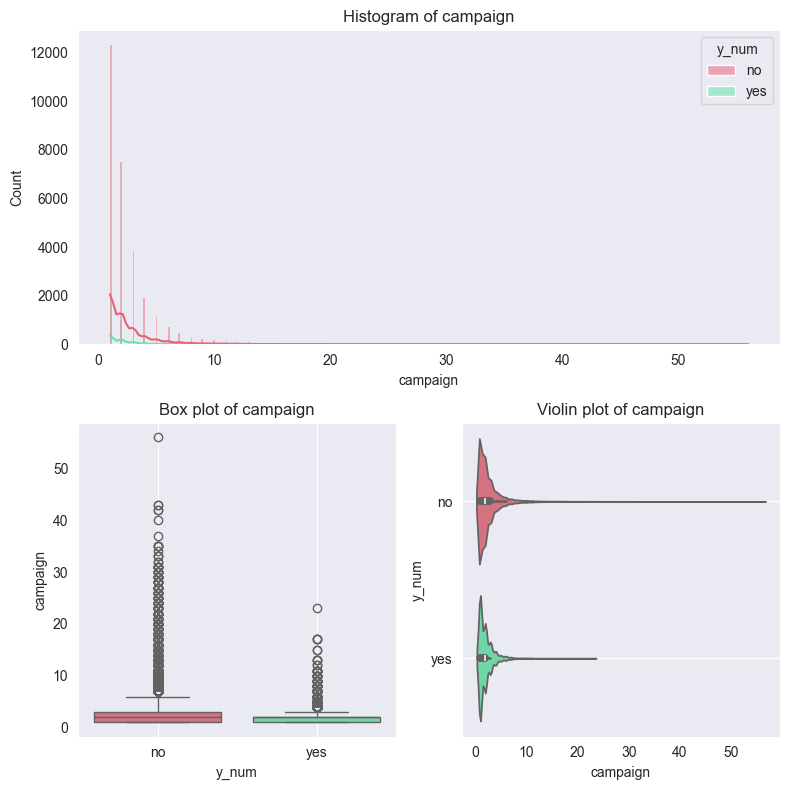

In [22]:
eda_numeric(train_df, 'campaign', target_col)

* The 'campaign' column contains numerical values; there are no missing values.
* Values range from 1 to 56 contacts, which appears realistic.
* The majority of clients (75% or more) had up to 3 contacts during the current campaign.
* Data visualization shows:
  - strong right-skewed distribution (skewness of 4.74)
  - outliers in the 'yes' group are significantly lower/smaller
  - the medians for 'yes' and 'no' are equal

**Hypothesis:** when the number of contacts exceeds ~10, the probability of a 'yes' response decreases. The column should be retained for model training as it may influence the target variable, particularly at higher campaign values.

### Analysis of the 'pdays' variable
– number of days that passed by after the client was last contacted from a previous campaign (999 means client was not previously contacted)

Since the 'pdays' column contains values of 999, which serves as a flag for no previous contact, it makes sense to conduct a separate preliminary analysis exclusively for clients who had prior contact with the bank.

In [23]:
# proportion of values in the 'pdays' column
(train_df.pdays.value_counts(normalize=True) * 100).to_frame().T

pdays,999,3,6,4,2,7,9,10,12,5,...,16,17,18,22,19,21,25,20,27,26
proportion,96.279211,1.07739,1.022762,0.294385,0.157815,0.14264,0.136571,0.130501,0.121396,0.121396,...,0.027314,0.024279,0.018209,0.009105,0.00607,0.00607,0.003035,0.003035,0.003035,0.003035


==================== Column: pdays ====================
Total number of values: 1226
Number of unique values: 26
Number of missing values: 0
Skewness: 1.55
Outliers: 73
Median "no": 6.0
Median "yes": 6.0
count    1226.00
mean        6.00
std         3.89
min         0.00
25%         3.00
50%         6.00
75%         7.00
max        27.00
Name: pdays, dtype: float64


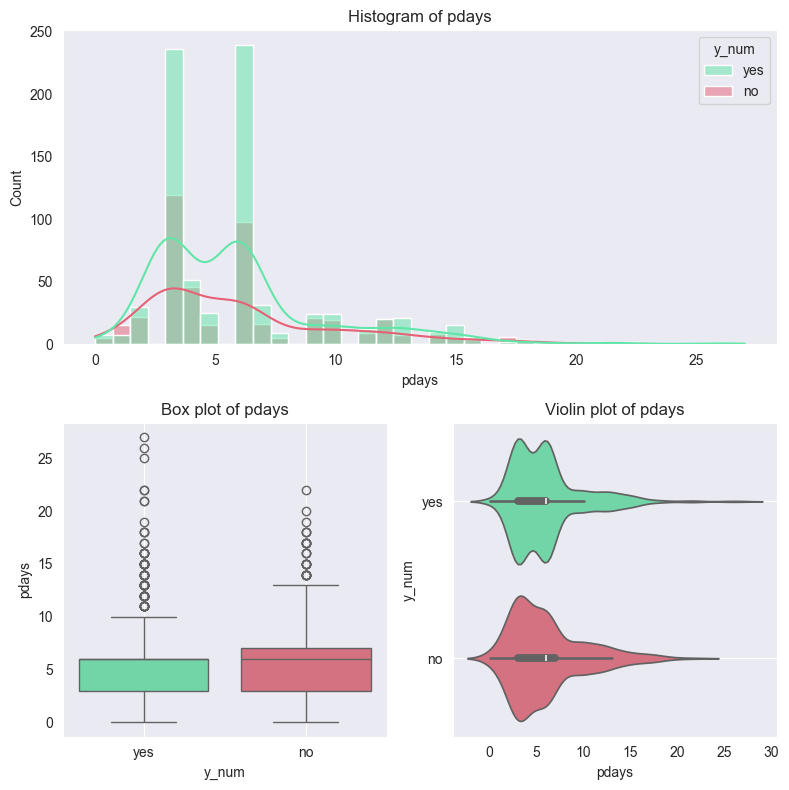

In [24]:
# data analysis with actual contacts (excluding 999)
eda_numeric(train_df[train_df.pdays != 999], 'pdays', target_col)

* The 'pdays' column contains numerical values; there are no missing values.
* The range of values (excluding 999, which serves as a flag for no previous contact) is from 0 to 27 days, which appears realistic.
* 50% of contacts occurred 6 or fewer days ago, and 75% occurred 7 or fewer days ago.
* The proportion of clients who had no contact with the bank in the previous campaign is 96%.
* For clients who were contacted in the previous campaign:
  - they account for ~4% of the total dataset
  - the distribution is right-skewed (skewness of 1.55), but the median value for both 'yes' and 'no' groups is identical (=6), and the distribution plots are similar.

**Hypothesis:** the numerical values of the 'pdays' feature are available for only a small subset of clients (under 4%) and are unlikely to serve as a strong predictor in their raw form. However, the mere fact of having prior contact may be an informative signal, so it is worth considering as a binary feature or combining it with other variables.

### Analysis of the 'previous' variable
– number of contacts performed before this campaign and for this client (numeric)

In [25]:
(train_df.previous.value_counts(normalize=True) * 100).to_frame().T

previous,0,1,2,3,4,5,6,7
proportion,86.239757,11.147193,1.83915,0.531108,0.182094,0.042489,0.015175,0.003035


==================== Column: previous ====================
Total number of values: 4534
Number of unique values: 7
Number of missing values: 0
Skewness: 3.04
Outliers: 861
Median "no": 1.0
Median "yes": 1.0
count    4534.00
mean        1.27
std         0.65
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         7.00
Name: previous, dtype: float64


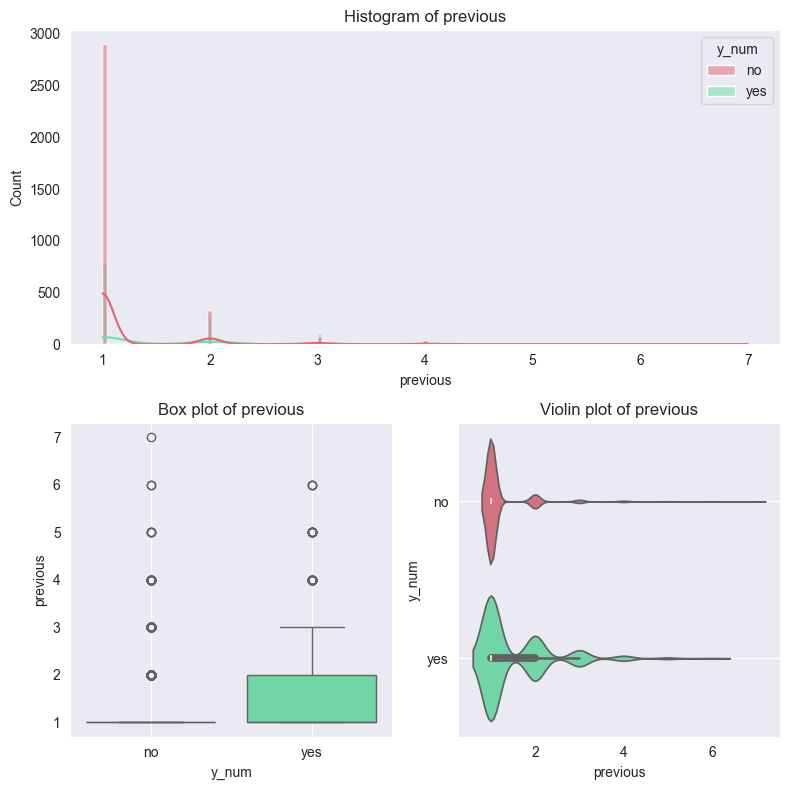

In [26]:
eda_numeric(train_df[train_df.previous != 0], 'previous', target_col)

* The 'previous' column contains numerical values; there are no missing values.
* Values range from 0 to 7 contacts, which appears realistic.
* The proportion of clients who had no contact with the bank prior to the current campaign is 86%.
* For clients who were contacted before the current campaign:
  - they account for ~14% of the total dataset
  - the distribution is right-skewed (skewness of 3.04), but the median value for both 'yes' and 'no' groups is identical (=1), and the distribution plots are similar.

**Hypothesis:** data on the number of prior contacts is available for only 14% of clients. Similar to the 'pdays' feature, it makes sense to treat this attribute as a binary feature (presence or absence of previous contact) or evaluate it in combination with other variables.

### Analysis of the 'poutcome' feature
– outcome of the previous marketing campaign

==================== Column: poutcome ====================
Total number of values: 32950
Number of unique values: 3
Number of missing values: 0


poutcome,nonexistent,failure,success
value_counts,28416.00,3429.00,1105.00
value_percentage,86.24,10.41,3.35


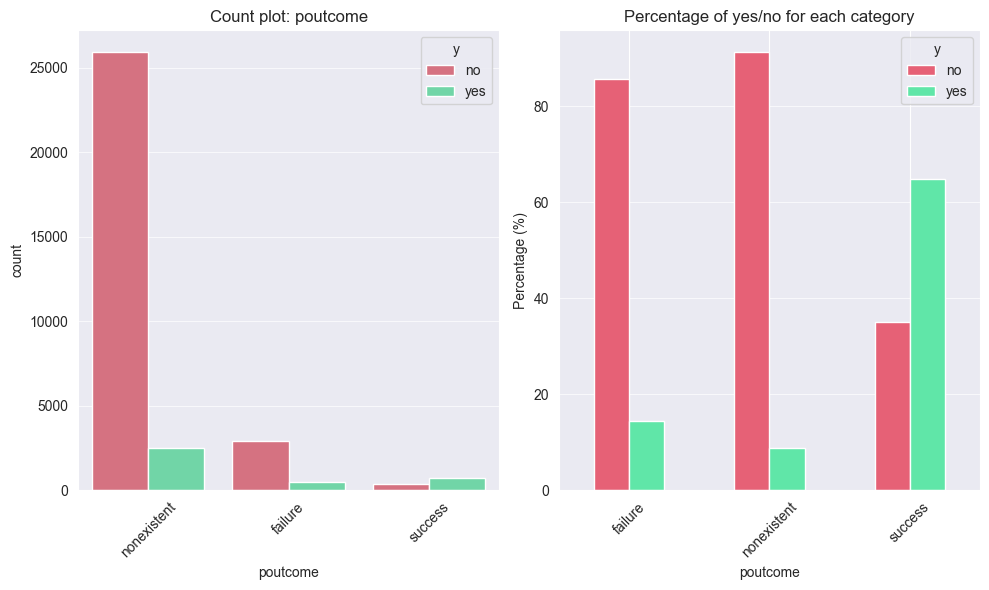

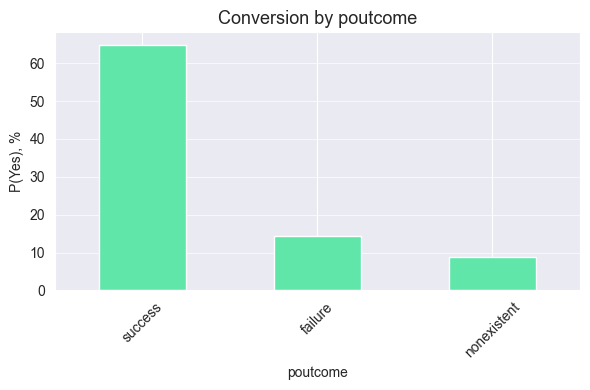

In [27]:
eda_category(train_df, 'poutcome', target_cat_col)

* The 'poutcome' column contains 32,950 observations and 3 unique categories; there are no missing values.
* Categories within this feature are imbalanced:
  - 'nonexistent' – ~86% of all observations
  - 'failure' – 10% of all observations
  - 'success' – 3% of all observations
* Data visualization shows a significant difference in conversion rates across categories:
  - 'nonexistent' – ~10%
  - 'failure' – ~15%
  - 'success' – ~65%

**Hypothesis:** the 'poutcome' feature is likely a significant predictor for the target variable, as there is a fairly strong relationship between the outcome of the previous campaign and the decision to open a deposit.

**Hypothesis for the "Other Attributes" block:**
- the 'poutcome' feature could become the strongest predictor (significant difference in conversion rates between categories)
- the 'pdays' and 'previous' features should likely be considered as binary variables
- the fairly significant drop in conversion rate when the number of contacts ('campaign') exceeds 10 should not be overlooked

## ANALYSIS OF SOCIAL AND ECONOMIC CONTEXT ATTRIBUTES

### Analysis of 'emp.var.rate'
– employment variation rate (quarterly indicator, numeric)

==================== Column: emp.var.rate ====================
Total number of values: 32950
Number of unique values: 10
Number of missing values: 0
Skewness: -0.72
Outliers: 0
Median "no": 1.1
Median "yes": -1.8
count    32950.00
mean         0.08
std          1.57
min         -3.40
25%         -1.80
50%          1.10
75%          1.40
max          1.40
Name: emp.var.rate, dtype: float64


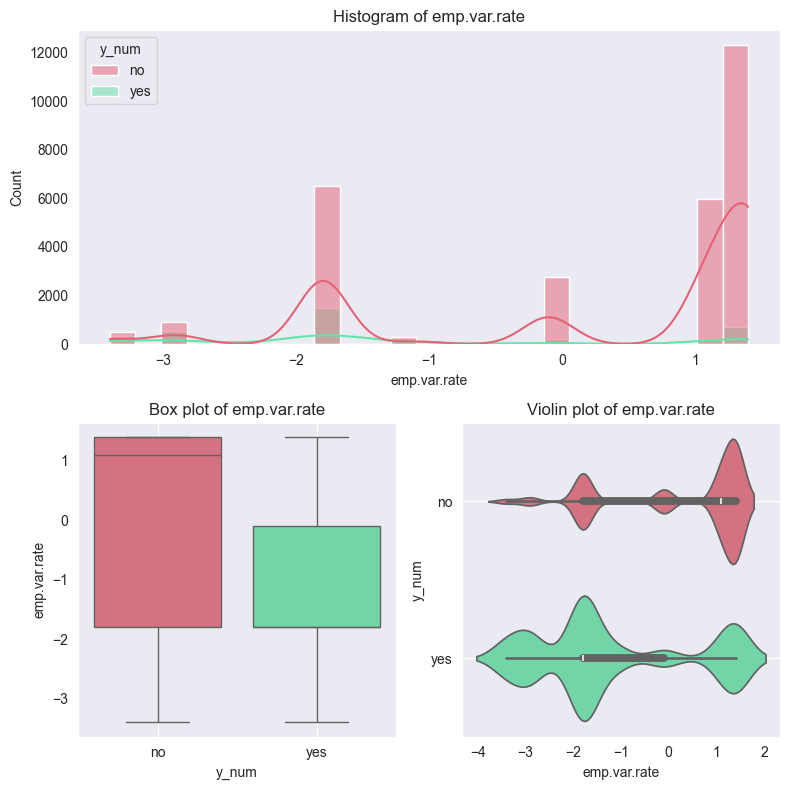

In [28]:
eda_numeric(train_df, 'emp.var.rate', target_col)

In [29]:
(train_df['emp.var.rate'].value_counts(normalize=True) * 100).to_frame().T

emp.var.rate,1.4,-1.8,1.1,-0.1,-2.9,-3.4,-1.7,-1.1,-3.0,-0.2
proportion,39.465857,22.327769,18.740516,8.925645,4.024279,2.60091,1.905918,1.575114,0.415781,0.018209


* The 'emp.var.rate' column contains numerical values; there are no missing values.
* Values range from -3.4 to 1.4, which appears realistic.
* Data visualization shows:
   - distinct peaks in values (10 in total), which may suggest that 'emp.var.rate' behaves like a categorical variable, even though it is numeric
   - a left-skewed distribution (skewness of -0.72)
   - distributions for the 'yes' and 'no' groups differ noticeably, with the median for 'yes' being significantly lower than that for 'no': -1.8 and 1.1, respectively.

**Hypothesis:** the 'emp.var.rate' feature could be a strong predictor for the target variable, as different employment variation rates may influence the likelihood of a positive response.

### Analysis of the 'cons.price.idx' variable
– consumer price index (monthly indicator, numeric)

==================== Column: cons.price.idx ====================
Total number of values: 32950
Number of unique values: 26
Number of missing values: 0
Skewness: -0.23
Outliers: 0
Median "no": 93.918
Median "yes": 93.2
count    32950.00
mean        93.58
std          0.58
min         92.20
25%         93.08
50%         93.75
75%         93.99
max         94.77
Name: cons.price.idx, dtype: float64


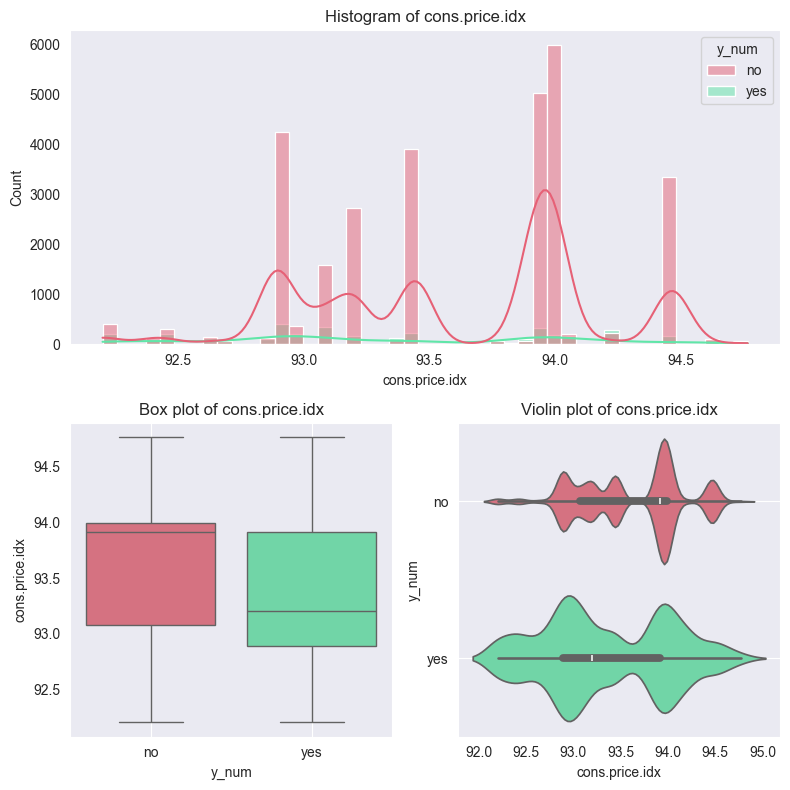

In [30]:
eda_numeric(train_df, 'cons.price.idx', target_col)

* The 'cons.price.idx' column contains numerical values; there are no missing values.
* Values range from 92.20 to 94.77, which appears realistic.
* Data visualization shows:
   - distinct peaks in values (26 in total), which may suggest that 'cons.price.idx' behaves like a categorical variable, even though it is numeric
   - slight left skewness (-0.23)
   - distributions for the 'yes' and 'no' groups differ noticeably; within the current range of values, the median for 'yes' is noticeably lower than the median for 'no': 93.2 and 93.9, respectively.

**Hypothesis:** the 'cons.price.idx' feature, like 'emp.var.rate', is a macroeconomic indicator and could be a useful predictor for the target variable, as shifts in the consumer price index, alongside other economic conditions, may influence the likelihood of a positive response.

### Analysis of the 'cons.conf.idx' variable
– consumer confidence index (monthly indicator, numeric)

==================== Column: cons.conf.idx ====================
Total number of values: 32950
Number of unique values: 26
Number of missing values: 0
Skewness: 0.31
Outliers: 359
Median "no": -41.8
Median "yes": -40.4
count    32950.00
mean       -40.51
std          4.63
min        -50.80
25%        -42.70
50%        -41.80
75%        -36.40
max        -26.90
Name: cons.conf.idx, dtype: float64


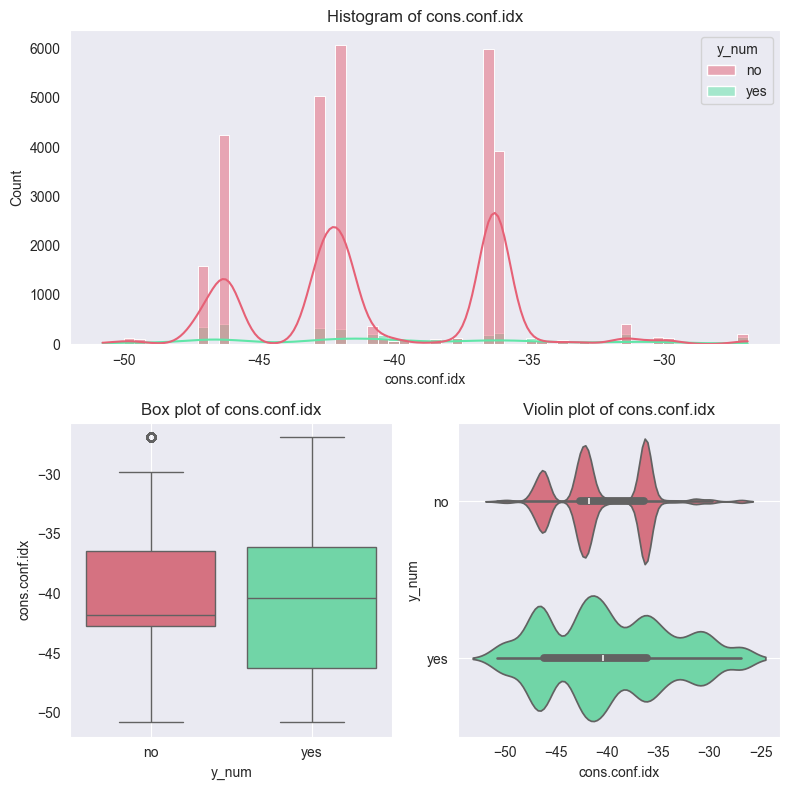

In [31]:
eda_numeric(train_df, 'cons.conf.idx', target_col)

* The 'cons.conf.idx' column contains numerical values; there are no missing values.
* Values range from -50.8 to -26.90, which appears realistic.
* Data visualization shows:
   - distinct peaks in values (26 unique values in total), which may suggest that 'cons.conf.idx' behaves like a categorical variable, even though it is numeric
   - slight right skewness (0.31)
   - distributions for the 'yes' and 'no' groups differ, as visible on the boxplots, although the difference between medians is relatively small: -40.4 for 'yes' and -41.8 for 'no'.

**Hypothesis:** the 'cons.conf.idx' feature is a macroeconomic indicator and may influence the likelihood of a positive customer response.

### Analysis of the 'euribor3m' variable
– 3-month Euribor rate (daily indicator, numeric)

==================== Column: euribor3m ====================
Total number of values: 32950
Number of unique values: 312
Number of missing values: 0
Skewness: -0.71
Outliers: 0
Median "no": 4.857
Median "yes": 1.266
count    32950.00
mean         3.62
std          1.74
min          0.63
25%          1.34
50%          4.86
75%          4.96
max          5.04
Name: euribor3m, dtype: float64


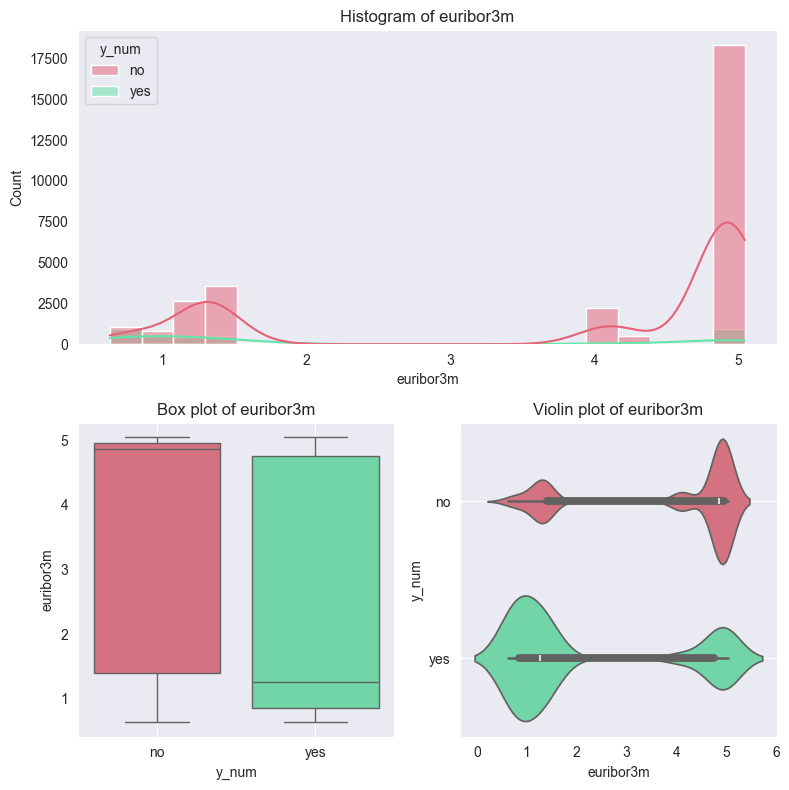

In [32]:
eda_numeric(train_df, 'euribor3m', target_col)

* The 'euribor3m' column contains numerical values; there are no missing values.
* Values range from 0.63 to 5.04, which appears realistic.
* Data visualization shows:
   - moderate left skewness (0.71)
   - distributions for the 'yes' and 'no' groups differ substantially: the median for 'no' (4.857) is close to the upper bound of the distribution, while the median for 'yes' (1.266) is much closer to the lower bound
   - the violin plot highlights high data density at opposite ends of the distribution for different classes: when the rate is low, the density of the 'yes' class is significantly higher, and conversely, at high rates, the 'no' class dominates

**Hypothesis:** the 'euribor3m' feature could be a strong predictor for the target variable.

### Analysis of the 'nr.employed' variable
– number of employees (quarterly indicator, numeric)

==================== Column: nr.employed ====================
Total number of values: 32950
Number of unique values: 11
Number of missing values: 0
Skewness: -1.04
Outliers: 0
Median "no": 5195.8
Median "yes": 5099.1
count    32950.00
mean      5166.90
std         72.43
min       4963.60
25%       5099.10
50%       5191.00
75%       5228.10
max       5228.10
Name: nr.employed, dtype: float64


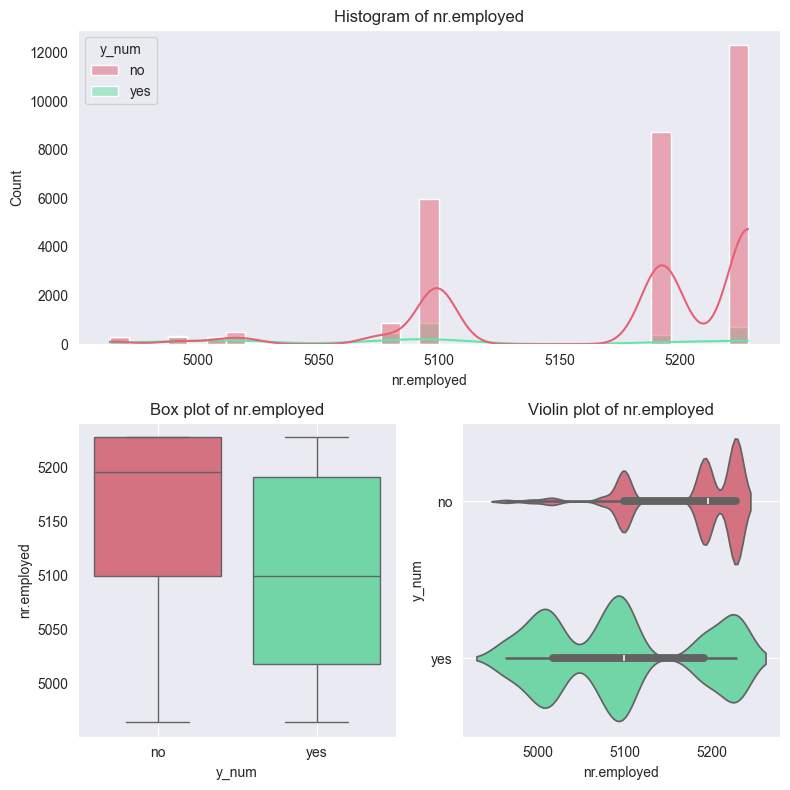

In [33]:
eda_numeric(train_df, 'nr.employed', target_col)

* The 'nr.employed' column contains numerical values; there are no missing values.
* Values range from 4,963.60 to 5,228.10 thousand people, which appears realistic.
* Data visualization shows:
   - distinct peaks in values (11 unique values in total), making the 'nr.employed' variable behave similarly to a categorical one, even though it is numeric
   - beyond the ~5,050 threshold, the number of 'no' responses increases sharply
   - moderate left skewness (-1.04)
   - distributions for the 'yes' and 'no' groups differ, as visible on the boxplots
   - the median of the 'yes' class almost coincides with the lower bound of the first quartile of the 'no' class.

**Hypothesis:** the 'nr.employed' feature is a macroeconomic indicator and may significantly influence the likelihood of a positive customer response.
It is also worth checking macroeconomic indicators for multicollinearity/correlation.

### Correlation analysis between macroeconomic indicators (social and economic context attributes)

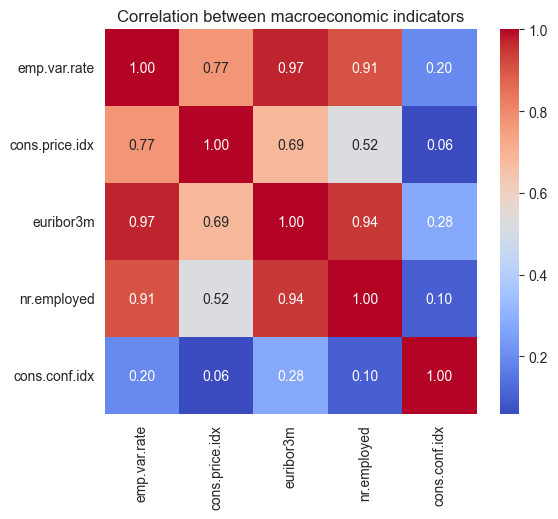

In [34]:
cols = [
    'emp.var.rate',
    'cons.price.idx',
    'euribor3m',
    'nr.employed',
    'cons.conf.idx'
]

plt.figure(figsize=(6, 5))
sns.heatmap(train_df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between macroeconomic indicators')
plt.show()

* Correlation analysis revealed a strong dependency (correlation coefficients exceeding 0.9) among the following macroeconomic indicators: 'emp.var.rate', 'euribor3m', and 'nr.employed'. These variables capture economic conditions that can influence customer deposit decisions: as these metrics rise, the likelihood of a positive response decreases.

* The variables 'cons.price.idx' and 'cons.conf.idx' exhibit moderate to very weak correlation with other economic metrics and can supply the model with complementary information.
* For Logistic Regression, regularization can be applied to mitigate unstable coefficients, which commonly affect linear models in the presence of multicollinearity.
* Non-linear models (kNN, Decision Trees, boosting algorithms) are less sensitive to multicollinearity, allowing all of these features to be used during training.

**Hypothesis for the "Social and Economic Context Attributes" Block:**
- 'emp.var.rate', 'euribor3m', and 'nr.employed' are likely to be the strongest predictors (showing more substantial differences in conversion rates across their values)
- 'cons.price.idx' and 'cons.conf.idx' are less pronounced, but may still add useful information
- there is a limited number of unique values, which could lead to unreliable estimation
- due to strong correlation among macroeconomic metrics, regularization should be applied to Logistic Regression to prevent unstable coefficients. For non-linear models, all features can be retained.

## **General EDA Conclusion**

* The exploratory data analysis revealed that the features in the dataset vary in their level of informativeness. The most significant predictors are likely to be those showing substantial distributional differences between the target classes:
  - client previous contact features (poutcome, previous, pdays)
  - current campaign parameters (contact, campaign)
  - macroeconomic indicators (euribor3m, emp.var.rate, nr.employed)

* Certain features (housing, loan, day_of_week) display a weak relationship with the target variable and are likely to have a limited impact on model performance.

* The 'duration' feature shows a strong correlation with the target variable, but because it is unknown prior to making a call decision, it should be excluded from model training to prevent data leakage.

* When utilizing linear models, the strong correlation among macroeconomic indicators must be taken into account.

* A substantial portion of the features reflects marketing campaign characteristics and macroeconomic conditions during a given time window rather than individual customer attributes. This nuance warrants careful consideration when interpreting model training results.